Chosen attractor seed:
Re(z_0) = 4.3643956198
Im(z_0) = -0.1379180148


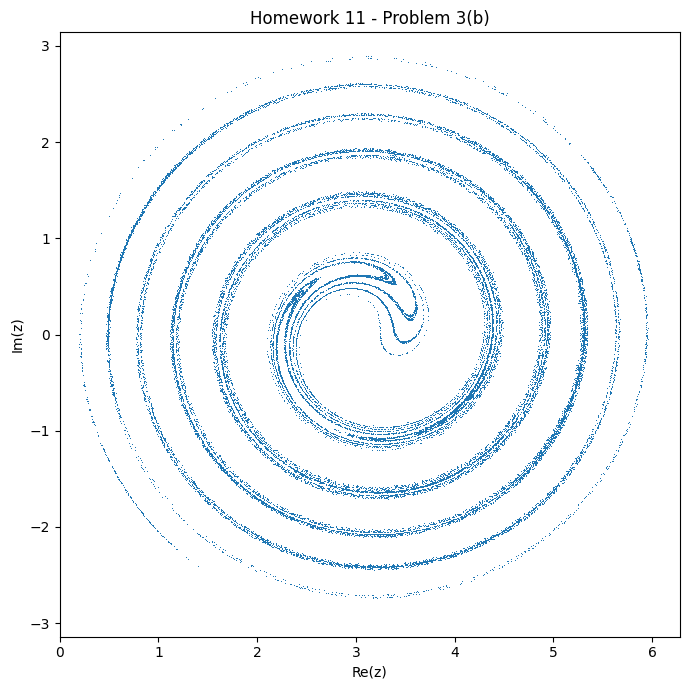

In [ ]:
# ###########################################################################
# Author: Edward E. Daisey
# Course: Modeling & Simulation of Complex Systems
# Title: Assignment 10 - Problem 3(b)
# Date: 14th of April 2026
# ###########################################################################

################################### Overview ##################################
# Description:
#   This script plots the attractor for the complex-valued iterated map
#
#       z_(n+1) = pi + (1/2) * z_n * exp(i * |z_n|^2)
#
#   where z_n = x_n + i y_n.
#
#   The assignment requests that we first try a few initial conditions and
#   generate a few thousand points to find the attractor. Then we use a point
#   on the attractor as the initial condition for the final plot.
#
# Requirements:
#   (1) Try a few initial conditions to locate the attractor
#   (2) Use a point on the attractor as the final initial condition
#   (3) Plot at least 2^15 points
#   (4) Set the plotting window to
#
#           0 <= Re(z) <= 2*pi
#          -pi <= Im(z) <= pi
#
# Output:
#   (1) Plot of the attractor for the complex iterated map
# ###########################################################################

# ############################ Imports ######################################
import math
import cmath
import numpy as np
import matplotlib.pyplot as plt
# ###########################################################################


# ############################ Constants ####################################
numberOfPlotPoints = 2 ** 15
explorationSteps = 5000

xMin = 0.0
xMax = 2.0 * math.pi
yMin = -math.pi
yMax = math.pi

initialConditions = [
    0.0 + 0.0j,
    math.pi + 1.0j,
    2.0 + 0.5j,
    4.0 - 1.0j
]
# ###########################################################################


# ############################ Function 1 ###################################
# Name:
#   IterateComplexMap
#
# Purpose:
#   Applies one iteration of the complex-valued map
#
#       z_(n+1) = pi + (1/2) * z_n * exp(i * |z_n|^2).
#
# Input:
#   currentZ : Current complex iterate z_n.
#
# Output:
#   The next complex iterate z_(n+1).
def IterateComplexMap(currentZ):
    nextZ = math.pi + 0.5 * currentZ * cmath.exp(1j * (abs(currentZ) ** 2))
    return nextZ
# ###########################################################################


# ############################ Function 2 ###################################
# Name:
#   IsInsidePlotWindow
#
# Purpose:
#   Checks whether a complex point lies inside the required plotting window.
#
# Input:
#   currentZ : Complex point to test.
#
# Output:
#   True if the point lies inside the plotting window, otherwise False.
def IsInsidePlotWindow(currentZ):
    realPart = currentZ.real
    imaginaryPart = currentZ.imag

    return (xMin <= realPart <= xMax) and (yMin <= imaginaryPart <= yMax)
# ###########################################################################


# ############################ Function 3 ###################################
# Name:
#   FindAttractorSeed
#
# Purpose:
#   Uses several initial conditions and a few thousand iterations to find a
#   point on the attractor. Preference is given to a point that lies inside
#   the required plotting window.
#
# Input:
#   None.
#
# Output:
#   attractorSeed : A complex point on the attractor to be used as the final
#                   initial condition.
def FindAttractorSeed():
    attractorSeed = None

    for initialZ in initialConditions:
        currentZ = initialZ

        for stepIndex in range(explorationSteps):
            currentZ = IterateComplexMap(currentZ)

            if IsInsidePlotWindow(currentZ):
                attractorSeed = currentZ

    if attractorSeed is None:
        attractorSeed = currentZ

    return attractorSeed
# ###########################################################################


# ############################ Function 4 ###################################
# Name:
#   GenerateAttractorPoints
#
# Purpose:
#   Generates the final trajectory used for plotting the attractor, starting
#   from a point already on the attractor.
#
# Input:
#   attractorSeed : Initial condition on the attractor.
#   totalPoints   : Number of points to generate.
#
# Output:
#   realValues    : Real parts of the generated points.
#   imagValues    : Imaginary parts of the generated points.
def GenerateAttractorPoints(attractorSeed, totalPoints):
    realValues = np.empty(totalPoints)
    imagValues = np.empty(totalPoints)

    currentZ = attractorSeed

    for pointIndex in range(totalPoints):
        realValues[pointIndex] = currentZ.real
        imagValues[pointIndex] = currentZ.imag
        currentZ = IterateComplexMap(currentZ)

    return realValues, imagValues
# ###########################################################################


# ############################ Function 5 ###################################
# Name:
#   PlotAttractor
#
# Purpose:
#   Plots the attractor in the required window
#
#       0 <= Re(z) <= 2*pi
#      -pi <= Im(z) <= pi.
#
# Input:
#   realValues : Real parts of the attractor points.
#   imagValues : Imaginary parts of the attractor points.
#
# Output:
#   Displays the requested attractor plot.
def PlotAttractor(realValues, imagValues):
    plt.figure(figsize=(7.0, 7.0))
    plt.plot(realValues, imagValues, ",")
    plt.xlim(xMin, xMax)
    plt.ylim(yMin, yMax)
    plt.xlabel("Re(z)")
    plt.ylabel("Im(z)")
    plt.title("Assignment 10 - Problem 3(b)")
    plt.tight_layout()
    plt.show()
# ###########################################################################


# ############################ Function 6 ###################################
# Name:
#   Main
#
# Purpose:
#   Finds a point on the attractor using several initial conditions, generates
#   the final trajectory from that attractor point, and displays the plot.
#
# Input:
#   None.
#
# Output:
#   Prints the chosen attractor seed and displays the attractor plot.
def Main():
    attractorSeed = FindAttractorSeed()

    print("Chosen attractor seed:")
    print(f"Re(z_0) = {attractorSeed.real:.10f}")
    print(f"Im(z_0) = {attractorSeed.imag:.10f}")

    realValues, imagValues = GenerateAttractorPoints(
        attractorSeed,
        numberOfPlotPoints
    )

    PlotAttractor(realValues, imagValues)
# ###########################################################################


# ############################# Execution ###################################
Main()
# ###########################################################################